In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [2]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
#mask=df_all_sorted["HG"]>2400
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
#df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_200101_001_0201_SEB.lv0
astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


In [3]:
def count_valid_pixels(row):
    hgev = np.array(row["HG"])
    ttpev = np.array(row["TTP"])
    pxmask = (hgev > 2400) & (ttpev < 255)
    return np.sum(pxmask)

df_all_sorted["n_valid_pixels"] = df_all_sorted.apply(count_valid_pixels, axis=1)
df_all_sorted = df_all_sorted[df_all_sorted["n_valid_pixels"] >= 8].reset_index(drop=True)
df_all_original = df_all_sorted.copy()


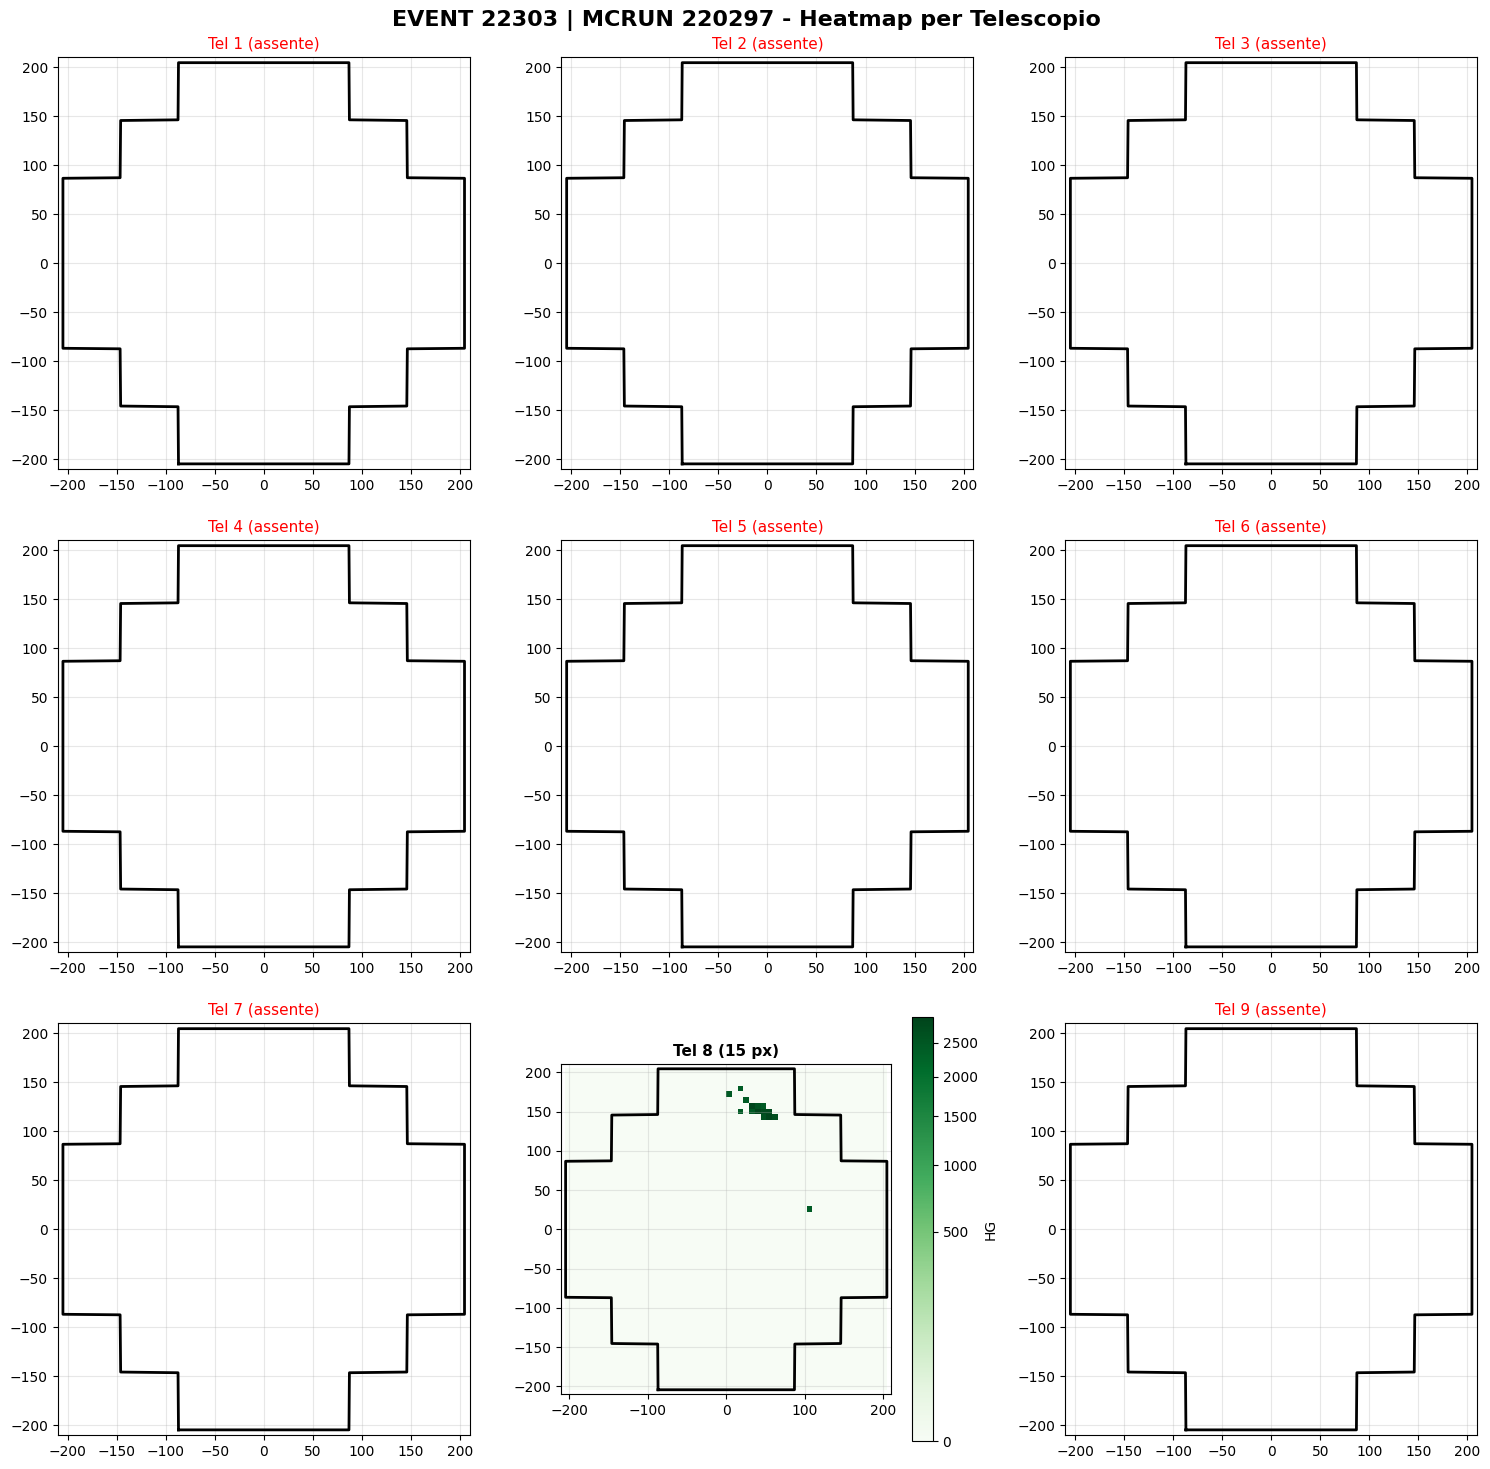

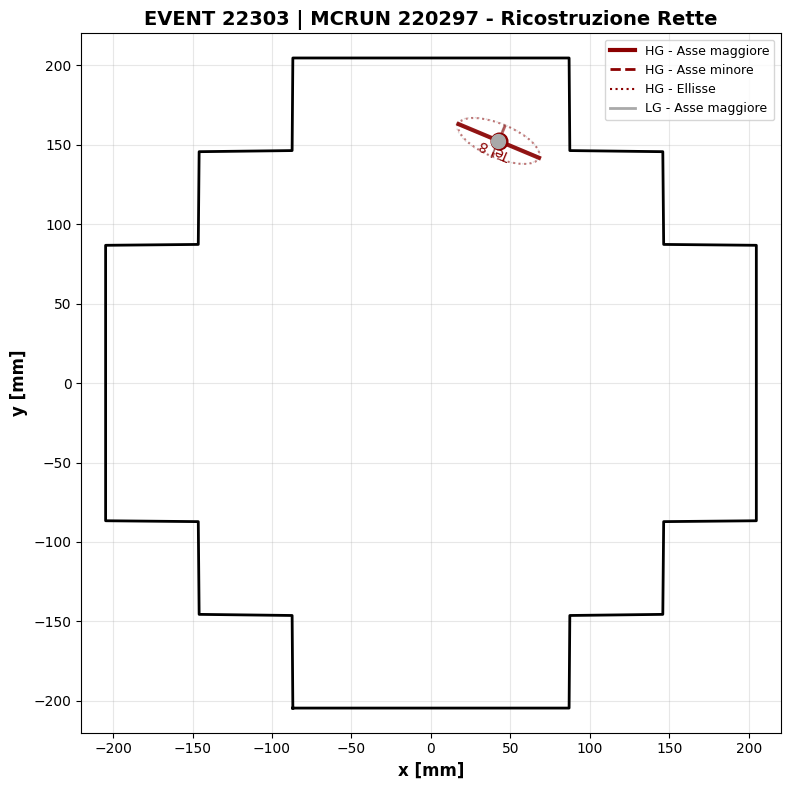


ANALISI EVENTO MC: 22303, MCRUN: 220297

 INFORMAZIONI GENERALI
  Telescopi presenti: [8]
  Numero telescopi: 1

 INFORMAZIONI TEMPORALI
 TEL_ID   TIME_NS  TIME_S   TIME_ABS
      8 419560103       2 2419560103

  TIME_ABS range: [2419560103, 2419560103]
  Delta temporale: 0.00 ns

RETTE RICOSTRUITE:
  Tel 8: centroide=(42.7, 152.3) mm, θ=157.3°, l1=188.2, l2=28.2

 TOTALE
  Rette HG ricostruite: 1
  Rette LG ricostruite: 1



In [4]:

from matplotlib.colors import PowerNorm
from matplotlib.patches import Ellipse

def analisi_evento_mc(event, mcrun):
    """
    Analizza un evento MC specifico mostrando:
    - Heatmap per ogni telescopio (griglia 3x3)
    - Plot con rette, assi principali/minori ed ellissi
    - Informazioni temporali
    """
    
    # Filtra dati per questo evento
    df_target = df_all_sorted[
        (df_all_sorted['EVENT'] == event) &
        (df_all_sorted['MCRUN'] == mcrun)
    ].sort_values(by='TEL_ID').copy()
    
    if len(df_target) == 0:
        print(f" Nessun dato per EVENT={event}, MCRUN={mcrun}")
        return None, None
    
    xfp, yfp = at.utils.camera.get_xy_footprint()
    y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
    x_pix = at.reshape(x_pix)
    y_pix = at.reshape(y_pix)
    
    # =========================================================================
    # 1. HEATMAP PER OGNI TELESCOPIO (griglia 3x3)
    # =========================================================================
    
    fig1, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    
    for itel in range(9):
        tel_id = itel + 1
        ax = axes[itel]
        
        tel_data = df_target[df_target['TEL_ID'] == tel_id]
        
        if len(tel_data) > 0:
            row_data = tel_data.iloc[0]
            hgev = np.array(row_data['HG'])
            ttpev = np.array(row_data['TTP'])
            
            pxmask = (hgev > 2400) & (ttpev < 255)
            n_pixels = np.sum(pxmask)
            
            if np.any(pxmask):
                h = ax.hist2d(x_pix[pxmask].flatten(), y_pix[pxmask].flatten(),
                             weights=hgev[pxmask].flatten(), 
                             range=((-205, 205), (-205, 205)),
                             bins=7*8, cmap='Greens', norm=PowerNorm(0.4))
                
                fig1.colorbar(h[3], ax=ax, label='HG')
                ax.set_title(f'Tel {tel_id} ({n_pixels} px)', fontsize=11, fontweight='bold')
            else:
                ax.set_title(f'Tel {tel_id} (no pixels)', fontsize=11, color='gray')
        else:
            ax.set_title(f'Tel {tel_id} (assente)', fontsize=11, color='red')
        
        ax.plot(xfp, yfp, 'k-', linewidth=2)
        ax.set_xlim(-210, 210)
        ax.set_ylim(-210, 210)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'EVENT {event} | MCRUN {mcrun} - Heatmap per Telescopio', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 2. PLOT CON RETTE, ASSI ED ELLISSI
    # =========================================================================
    
    fig2, ax = plt.subplots(figsize=(8, 8))
    
    rette_hg = []
    rette_lg = []
    
    for _, row_data in df_target.iterrows():
        tel_id = row_data['TEL_ID']
        hgev = np.array(row_data['HG'])
        lgev = np.array(row_data['LG'])
        ttpev = np.array(row_data['TTP'])
        
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # ==================== SIGMA CLIPPING ====================
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()
        
        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)
        
        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)
        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)
        
        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ==================== CENTROIDI ====================
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)
        
        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)
        
        # ==================== COVARIANZE ====================
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        
        # Autovalori (asse maggiore e minore)
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        l2_hg = (cov_hg[0,0] + cov_hg[1,1])/2 - np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        l2_lg = (cov_lg[0,0] + cov_lg[1,1])/2 - np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        # Testo vicino alla retta HG
        dx = np.cos(theta_hg)
        dy = np.sin(theta_hg)
        nx, ny = -dy, dx   # normale alla retta
        offset = 6         # distanza dal centro (mm)

        ax.text(meanx_hg + offset * nx, meany_hg + offset * ny,
                f"Tel {tel_id}",
                fontsize=10, color='darkred',
                rotation=np.degrees(theta_hg),
                rotation_mode='anchor',
                ha='center', va='center')
        # Salva rette
        rette_hg.append({
            "p0": np.array([meanx_hg, meany_hg]),
            "d": np.array([np.cos(theta_hg), np.sin(theta_hg)]),
            "l1": l1_hg,
            "l2": l2_hg,
            "tel": tel_id,
            "mc_run": mcrun,
            "event": event
        })
        
        rette_lg.append({
            "p0": np.array([meanx_lg, meany_lg]),
            "d": np.array([np.cos(theta_lg), np.sin(theta_lg)]),
            "l1": l1_lg,
            "l2": l2_lg,
            "tel": tel_id
        })
        
        # ==================== PLOT HG ====================
        
        # Centroide
        ax.plot(meanx_hg, meany_hg, 'o', markersize=12, color='darkred', zorder=6)
        
        # Asse principale (maggiore)
        L1_hg = 2 * np.sqrt(l1_hg)
        ax.plot([meanx_hg - L1_hg * np.cos(theta_hg), meanx_hg + L1_hg * np.cos(theta_hg)],
                [meany_hg - L1_hg * np.sin(theta_hg), meany_hg + L1_hg * np.sin(theta_hg)],
                '-', color='darkred', linewidth=3, alpha=0.9, zorder=5)
        
        # Asse minore
        theta_minor_hg = theta_hg + np.pi/2
        L2_hg = 2 * np.sqrt(l2_hg)
        ax.plot([meanx_hg - L2_hg * np.cos(theta_minor_hg), meanx_hg + L2_hg * np.cos(theta_minor_hg)],
                [meany_hg - L2_hg * np.sin(theta_minor_hg), meany_hg + L2_hg * np.sin(theta_minor_hg)],
                '--', color='darkred', linewidth=2, alpha=0.6, zorder=5)
        
        # Ellisse
        ellipse_hg = Ellipse((meanx_hg, meany_hg), 
                            width=2*L1_hg, height=2*L2_hg,
                            angle=np.degrees(theta_hg),
                            facecolor='none', edgecolor='darkred', 
                            linewidth=1.5, linestyle=':', alpha=0.5, zorder=4)
        ax.add_patch(ellipse_hg)
        
        # ==================== PLOT LG ====================
        
        # Centroide
        ax.plot(meanx_lg, meany_lg, 'o', markersize=10, color='darkgrey', zorder=6)
        
        # Asse principale
        L1_lg = 2 * np.sqrt(l1_lg)
        ax.plot([meanx_lg - L1_lg * np.cos(theta_lg), meanx_lg + L1_lg * np.cos(theta_lg)],
                [meany_lg - L1_lg * np.sin(theta_lg), meany_lg + L1_lg * np.sin(theta_lg)],
                '-', color='darkgrey', linewidth=2, alpha=0.7, zorder=4)
        
        # Asse minore
        theta_minor_lg = theta_lg + np.pi/2
        L2_lg = 2 * np.sqrt(l2_lg)
        ax.plot([meanx_lg - L2_lg * np.cos(theta_minor_lg), meanx_lg + L2_lg * np.cos(theta_minor_lg)],
                [meany_lg - L2_lg * np.sin(theta_minor_lg), meany_lg + L2_lg * np.sin(theta_minor_lg)],
                '--', color='darkgrey', linewidth=1.5, alpha=0.5, zorder=4)
        
        # Ellisse
        ellipse_lg = Ellipse((meanx_lg, meany_lg), 
                            width=2*L1_lg, height=2*L2_lg,
                            angle=np.degrees(theta_lg),
                            facecolor='none', edgecolor='darkgrey', 
                            linewidth=1, linestyle=':', alpha=0.4, zorder=3)
        ax.add_patch(ellipse_lg)
    
    # Footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
    ax.set_xlim(-220, 220)
    ax.set_ylim(-220, 220)
    ax.set_aspect('equal')
    ax.set_xlabel('x [mm]', fontsize=12, fontweight='bold')
    ax.set_ylabel('y [mm]', fontsize=12, fontweight='bold')
    ax.set_title(f'EVENT {event} | MCRUN {mcrun} - Ricostruzione Rette', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Legenda
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='darkred', lw=3, label='HG - Asse maggiore'),
        Line2D([0], [0], color='darkred', lw=2, linestyle='--', label='HG - Asse minore'),
        Line2D([0], [0], color='darkred', lw=1.5, linestyle=':', label='HG - Ellisse'),
        Line2D([0], [0], color='darkgrey', lw=2, label='LG - Asse maggiore')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 3. STAMPA INFORMAZIONI FINALI
    # =========================================================================
    
    print(f"\n{'='*80}")
    print(f"ANALISI EVENTO MC: {event}, MCRUN: {mcrun}")
    print(f"{'='*80}\n")
    
    telescopi_presenti = df_target['TEL_ID'].values
    n_telescopi = len(telescopi_presenti)
    
    print(f" INFORMAZIONI GENERALI")
    print(f"  Telescopi presenti: {list(telescopi_presenti)}")
    print(f"  Numero telescopi: {n_telescopi}")
    
    print(f"\n INFORMAZIONI TEMPORALI")
    print(df_target[["TEL_ID", "TIME_NS", "TIME_S", "TIME_ABS"]].to_string(index=False))
    
    time_abs_vals = df_target['TIME_ABS'].values
    print(f"\n  TIME_ABS range: [{time_abs_vals.min()}, {time_abs_vals.max()}]")
    print(f"  Delta temporale: {time_abs_vals.max() - time_abs_vals.min():.2f} ns")
    
    print(f"\nRETTE RICOSTRUITE:")
    for retta in rette_hg:
        tel = retta['tel']
        cx, cy = retta['p0']
        theta = np.arctan2(retta['d'][1], retta['d'][0])
        print(f"  Tel {tel}: centroide=({cx:.1f}, {cy:.1f}) mm, θ={np.degrees(theta):.1f}°, l1={retta['l1']:.1f}, l2={retta['l2']:.1f}")
    
    print(f"\n TOTALE")
    print(f"  Rette HG ricostruite: {len(rette_hg)}")
    print(f"  Rette LG ricostruite: {len(rette_lg)}\n")
    
    return rette_hg, rette_lg

#40514 40603] | MCRUN: [220283]

rette_hg, rette_lg = analisi_evento_mc(22303, 220297)


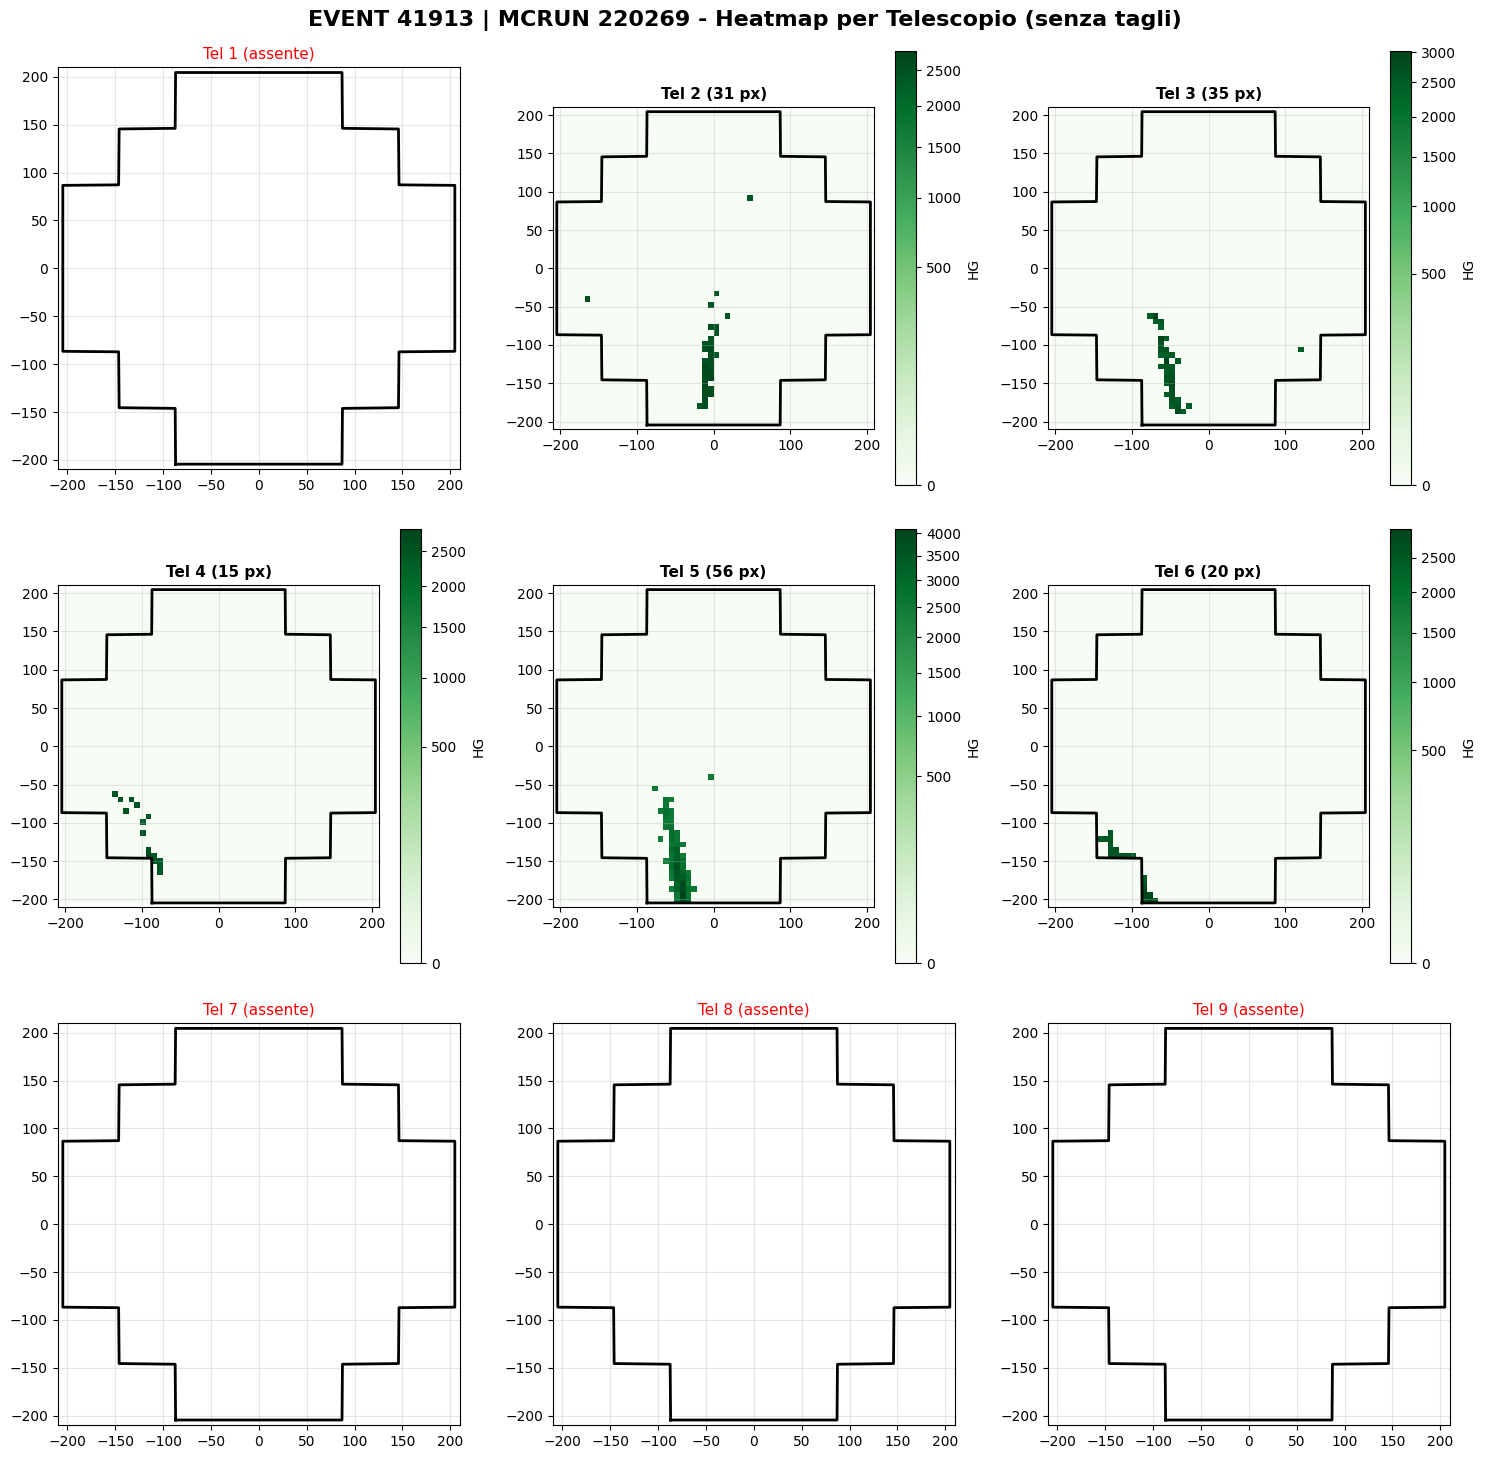

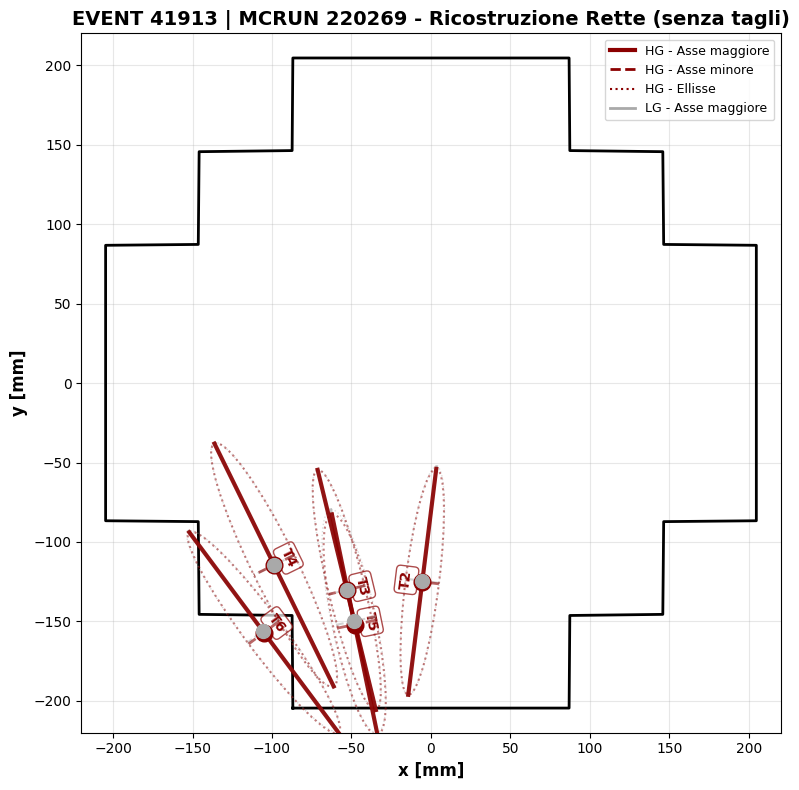


ANALISI EVENTO MC: 41913, MCRUN: 220269 (senza tagli)

 INFORMAZIONI GENERALI
  Telescopi presenti: [2, 3, 4, 5, 6]
  Numero telescopi: 5

 INFORMAZIONI TEMPORALI
 TEL_ID   TIME_NS  TIME_S   TIME_ABS
      2 725220614       1 1725220614
      3 725220644       1 1725220644
      4 725220654       1 1725220654
      5 725220858       1 1725220858
      6 725220889       1 1725220889

  TIME_ABS range: [1725220614, 1725220889]
  Delta temporale: 275.00 ns

RETTE RICOSTRUITE:
  Tel 2: centroide=(-5.5, -125.1) mm, θ=82.9°, l1=1281.8, l2=27.7
  Tel 3: centroide=(-53.0, -130.2) mm, θ=103.6°, l1=1510.7, l2=32.8
  Tel 4: centroide=(-98.7, -114.5) mm, θ=116.2°, l1=1809.6, l2=50.4
  Tel 5: centroide=(-48.0, -151.9) mm, θ=101.7°, l1=1252.0, l2=45.9
  Tel 6: centroide=(-105.1, -157.0) mm, θ=126.7°, l1=1546.1, l2=35.9

 TOTALE
  Rette HG ricostruite: 5
  Rette LG ricostruite: 5



In [7]:
def analisi_evento_mc(event, mcrun, cuts=False, show_ellipse=True):
    """
    Analizza un evento MC specifico mostrando:
    - Heatmap per ogni telescopio (griglia 3x3) con opzionalmente rette ed ellissi
    - Plot con rette, assi principali/minori ed ellissi
    - Informazioni temporali
    
    Parametri:
    ----------
    event : int
        Numero evento
    mcrun : int
        Numero run MC
    cuts : bool, default=False
        Se True, applica i tagli su n_valid_pixels e shape già definiti
    show_ellipse : bool, default=True
        Se True, mostra rette ed ellissi anche sui plot individuali dei telescopi
    """
    
    # Scegli il dataframe da usare
    if cuts:
        df_source = df_all_sorted  # Usa il dataframe già filtrato
        cut_info = "con tagli applicati"
    else:
        # Usa il dataframe originale senza filtri
        df_source = df_all_sorted  
        cut_info = "senza tagli"
    
    # Filtra dati per questo evento
    df_target = df_source[
        (df_source['EVENT'] == event) &
        (df_source['MCRUN'] == mcrun)
    ].sort_values(by='TEL_ID').copy()
    
    if len(df_target) == 0:
        print(f" Nessun dato per EVENT={event}, MCRUN={mcrun} ({cut_info})")
        return None, None
    
    xfp, yfp = at.utils.camera.get_xy_footprint()
    y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
    x_pix = at.reshape(x_pix)
    y_pix = at.reshape(y_pix)
    
    # Dictionary per salvare i parametri di ogni telescopio
    tel_params = {}
    
    # =========================================================================
    # PRE-CALCOLO: Calcola parametri per tutti i telescopi
    # =========================================================================
    
    for _, row_data in df_target.iterrows():
        tel_id = row_data['TEL_ID']
        hgev = np.array(row_data['HG'])
        lgev = np.array(row_data['LG'])
        ttpev = np.array(row_data['TTP'])
        
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # ==================== SIGMA CLIPPING ====================
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()
        
        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)
        
        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)
        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)
        
        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ==================== CENTROIDI ====================
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)
        
        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)
        
        # ==================== COVARIANZE ====================
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        
        # Autovalori (asse maggiore e minore)
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        l2_hg = (cov_hg[0,0] + cov_hg[1,1])/2 - np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        l2_lg = (cov_lg[0,0] + cov_lg[1,1])/2 - np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        
        # Salva parametri
        tel_params[tel_id] = {
            'meanx_hg': meanx_hg, 'meany_hg': meany_hg,
            'meanx_lg': meanx_lg, 'meany_lg': meany_lg,
            'theta_hg': theta_hg, 'theta_lg': theta_lg,
            'l1_hg': l1_hg, 'l2_hg': l2_hg,
            'l1_lg': l1_lg, 'l2_lg': l2_lg
        }
    
    # =========================================================================
    # 1. HEATMAP PER OGNI TELESCOPIO (griglia 3x3)
    # =========================================================================
    
    fig1, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    
    for itel in range(9):
        tel_id = itel + 1
        ax = axes[itel]
        
        tel_data = df_target[df_target['TEL_ID'] == tel_id]
        
        if len(tel_data) > 0:
            row_data = tel_data.iloc[0]
            hgev = np.array(row_data['HG'])
            ttpev = np.array(row_data['TTP'])
            
            pxmask = (hgev > 2400) & (ttpev < 255)
            n_pixels = np.sum(pxmask)
            
            if np.any(pxmask):
                h = ax.hist2d(x_pix[pxmask].flatten(), y_pix[pxmask].flatten(),
                             weights=hgev[pxmask].flatten(), 
                             range=((-205, 205), (-205, 205)),
                             bins=7*8, cmap='Greens', norm=PowerNorm(0.4))
                
                # Aggiungi colorbar solo se ci sono dati
                if h[0].max() > 0:
                    fig1.colorbar(h[3], ax=ax, label='HG')
                
                ax.set_title(f'Tel {tel_id} ({n_pixels} px)', fontsize=11, fontweight='bold')
                
                # ==================== AGGIUNGI RETTE ED ELLISSI ====================
                if show_ellipse and tel_id in tel_params:
                    p = tel_params[tel_id]
                    
                    # HG: Centroide
                    ax.plot(p['meanx_hg'], p['meany_hg'], 'o', markersize=8, 
                           color='darkred', zorder=10)
                    
                    # HG: Asse principale
                    L1_hg = 2 * np.sqrt(p['l1_hg'])
                    ax.plot([p['meanx_hg'] - L1_hg * np.cos(p['theta_hg']), 
                            p['meanx_hg'] + L1_hg * np.cos(p['theta_hg'])],
                           [p['meany_hg'] - L1_hg * np.sin(p['theta_hg']), 
                            p['meany_hg'] + L1_hg * np.sin(p['theta_hg'])],
                           '-', color='darkred', linewidth=2.5, alpha=0.9, zorder=9)
                    
                    # HG: Asse minore
                    theta_minor_hg = p['theta_hg'] + np.pi/2
                    L2_hg = 2 * np.sqrt(p['l2_hg'])
                    ax.plot([p['meanx_hg'] - L2_hg * np.cos(theta_minor_hg), 
                            p['meanx_hg'] + L2_hg * np.cos(theta_minor_hg)],
                           [p['meany_hg'] - L2_hg * np.sin(theta_minor_hg), 
                            p['meany_hg'] + L2_hg * np.sin(theta_minor_hg)],
                           '--', color='darkred', linewidth=1.5, alpha=0.7, zorder=9)
                    
                    # HG: Ellisse
                    ellipse_hg = Ellipse((p['meanx_hg'], p['meany_hg']), 
                                        width=2*L1_hg, height=2*L2_hg,
                                        angle=np.degrees(p['theta_hg']),
                                        facecolor='none', edgecolor='darkred', 
                                        linewidth=1.5, linestyle=':', alpha=0.6, zorder=8)
                    ax.add_patch(ellipse_hg)
                    
            else:
                ax.set_title(f'Tel {tel_id} (no pixels)', fontsize=11, color='gray')
        else:
            ax.set_title(f'Tel {tel_id} (assente)', fontsize=11, color='red')
        
        ax.plot(xfp, yfp, 'k-', linewidth=2)
        ax.set_xlim(-210, 210)
        ax.set_ylim(-210, 210)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'EVENT {event} | MCRUN {mcrun} - Heatmap per Telescopio ({cut_info})', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 2. PLOT CON RETTE, ASSI ED ELLISSI
    # =========================================================================
    
    fig2, ax = plt.subplots(figsize=(8, 8))
    
    rette_hg = []
    rette_lg = []
    
    for tel_id, p in tel_params.items():
        
        # Salva rette
        rette_hg.append({
            "p0": np.array([p['meanx_hg'], p['meany_hg']]),
            "d": np.array([np.cos(p['theta_hg']), np.sin(p['theta_hg'])]),
            "l1": p['l1_hg'],
            "l2": p['l2_hg'],
            "tel": tel_id,
            "mc_run": mcrun,
            "event": event
        })
        
        rette_lg.append({
            "p0": np.array([p['meanx_lg'], p['meany_lg']]),
            "d": np.array([np.cos(p['theta_lg']), np.sin(p['theta_lg'])]),
            "l1": p['l1_lg'],
            "l2": p['l2_lg'],
            "tel": tel_id
        })
        
        # ==================== PLOT HG ====================
        
        # Centroide
        ax.plot(p['meanx_hg'], p['meany_hg'], 'o', markersize=12, color='darkred', zorder=6)
        
        # Asse principale (maggiore)
        L1_hg = 2 * np.sqrt(p['l1_hg'])
        ax.plot([p['meanx_hg'] - L1_hg * np.cos(p['theta_hg']), 
                p['meanx_hg'] + L1_hg * np.cos(p['theta_hg'])],
               [p['meany_hg'] - L1_hg * np.sin(p['theta_hg']), 
                p['meany_hg'] + L1_hg * np.sin(p['theta_hg'])],
               '-', color='darkred', linewidth=3, alpha=0.9, zorder=5)
        
        # Asse minore
        theta_minor_hg = p['theta_hg'] + np.pi/2
        L2_hg = 2 * np.sqrt(p['l2_hg'])
        ax.plot([p['meanx_hg'] - L2_hg * np.cos(theta_minor_hg), 
                p['meanx_hg'] + L2_hg * np.cos(theta_minor_hg)],
               [p['meany_hg'] - L2_hg * np.sin(theta_minor_hg), 
                p['meany_hg'] + L2_hg * np.sin(theta_minor_hg)],
               '--', color='darkred', linewidth=2, alpha=0.6, zorder=5)
        
        # Ellisse
        ellipse_hg = Ellipse((p['meanx_hg'], p['meany_hg']), 
                            width=2*L1_hg, height=2*L2_hg,
                            angle=np.degrees(p['theta_hg']),
                            facecolor='none', edgecolor='darkred', 
                            linewidth=1.5, linestyle=':', alpha=0.5, zorder=4)
        ax.add_patch(ellipse_hg)
        
        # Testo migliorato (non al contrario)
        dx = np.cos(p['theta_hg'])
        dy = np.sin(p['theta_hg'])
        nx, ny = -dy, dx   # normale alla retta
        offset = 10        # distanza dal centro (mm)
        
        # Calcola angolo per il testo (sempre leggibile)
        text_angle = np.degrees(p['theta_hg'])
        # Evita testo sottosopra: se l'angolo è tra 90° e 270°, ruota di 180°
        if 90 < text_angle % 360 < 270:
            text_angle += 180
            nx, ny = -nx, -ny  # inverti anche l'offset
        
        ax.text(p['meanx_hg'] + offset * nx, p['meany_hg'] + offset * ny,
                f"T{tel_id}",
                fontsize=10, color='darkred', fontweight='bold',
                rotation=text_angle,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='darkred', alpha=0.7))
        
        # ==================== PLOT LG ====================
        
        # Centroide
        ax.plot(p['meanx_lg'], p['meany_lg'], 'o', markersize=10, color='darkgrey', zorder=6)
        
        # Asse principale
        L1_lg = 2 * np.sqrt(p['l1_lg'])
        ax.plot([p['meanx_lg'] - L1_lg * np.cos(p['theta_lg']), 
                p['meanx_lg'] + L1_lg * np.cos(p['theta_lg'])],
               [p['meany_lg'] - L1_lg * np.sin(p['theta_lg']), 
                p['meany_lg'] + L1_lg * np.sin(p['theta_lg'])],
               '-', color='darkgrey', linewidth=2, alpha=0.7, zorder=4)
        
        # Asse minore
        theta_minor_lg = p['theta_lg'] + np.pi/2
        L2_lg = 2 * np.sqrt(p['l2_lg'])
        ax.plot([p['meanx_lg'] - L2_lg * np.cos(theta_minor_lg), 
                p['meanx_lg'] + L2_lg * np.cos(theta_minor_lg)],
               [p['meany_lg'] - L2_lg * np.sin(theta_minor_lg), 
                p['meany_lg'] + L2_lg * np.sin(theta_minor_lg)],
               '--', color='darkgrey', linewidth=1.5, alpha=0.5, zorder=4)
        
        # Ellisse
        ellipse_lg = Ellipse((p['meanx_lg'], p['meany_lg']), 
                            width=2*L1_lg, height=2*L2_lg,
                            angle=np.degrees(p['theta_lg']),
                            facecolor='none', edgecolor='darkgrey', 
                            linewidth=1, linestyle=':', alpha=0.4, zorder=3)
        ax.add_patch(ellipse_lg)
    
    # Footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
    ax.set_xlim(-220, 220)
    ax.set_ylim(-220, 220)
    ax.set_aspect('equal')
    ax.set_xlabel('x [mm]', fontsize=12, fontweight='bold')
    ax.set_ylabel('y [mm]', fontsize=12, fontweight='bold')
    ax.set_title(f'EVENT {event} | MCRUN {mcrun} - Ricostruzione Rette ({cut_info})', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Legenda
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='darkred', lw=3, label='HG - Asse maggiore'),
        Line2D([0], [0], color='darkred', lw=2, linestyle='--', label='HG - Asse minore'),
        Line2D([0], [0], color='darkred', lw=1.5, linestyle=':', label='HG - Ellisse'),
        Line2D([0], [0], color='darkgrey', lw=2, label='LG - Asse maggiore')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # 3. STAMPA INFORMAZIONI FINALI
    # =========================================================================
    
    print(f"\n{'='*80}")
    print(f"ANALISI EVENTO MC: {event}, MCRUN: {mcrun} ({cut_info})")
    print(f"{'='*80}\n")
    
    telescopi_presenti = df_target['TEL_ID'].values
    n_telescopi = len(telescopi_presenti)
    
    print(f" INFORMAZIONI GENERALI")
    print(f"  Telescopi presenti: {list(telescopi_presenti)}")
    print(f"  Numero telescopi: {n_telescopi}")
    
    print(f"\n INFORMAZIONI TEMPORALI")
    print(df_target[["TEL_ID", "TIME_NS", "TIME_S", "TIME_ABS"]].to_string(index=False))
    
    time_abs_vals = df_target['TIME_ABS'].values
    print(f"\n  TIME_ABS range: [{time_abs_vals.min()}, {time_abs_vals.max()}]")
    print(f"  Delta temporale: {time_abs_vals.max() - time_abs_vals.min():.2f} ns")
    
    print(f"\nRETTE RICOSTRUITE:")
    for retta in rette_hg:
        tel = retta['tel']
        cx, cy = retta['p0']
        theta = np.arctan2(retta['d'][1], retta['d'][0])
        print(f"  Tel {tel}: centroide=({cx:.1f}, {cy:.1f}) mm, θ={np.degrees(theta):.1f}°, l1={retta['l1']:.1f}, l2={retta['l2']:.1f}")
    
    print(f"\n TOTALE")
    print(f"  Rette HG ricostruite: {len(rette_hg)}")
    print(f"  Rette LG ricostruite: {len(rette_lg)}\n")
    
    return rette_hg, rette_lg
rette_hg, rette_lg = analisi_evento_mc(41913,220269 , cuts=False, show_ellipse=False)
#41912 41913] | MCRUN: [220269]